In [6]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Seattle911_XGB_5fold")
    .config("spark.executor.memory", "4g")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

# ============================================================
# 2. Data Import
# ============================================================
data_path = "../data/processed/calldata_20251019_processed_v4.csv"

df = spark.read.csv(data_path, header=True, inferSchema=True)
print(f"Loaded {df.count():,} rows with {len(df.columns)} columns")

Loaded 583,022 rows with 54 columns


In [7]:
# ============================================================
# 3. Data Filtering and Feature Setup
# ============================================================
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from xgboost.spark import SparkXGBRegressor

# Target variable (SPD response time)
label_col = "call_sign_total_service_time_s"

df = (
    df.filter(F.col(label_col).isNotNull())
      .filter(
          (F.col("dispatch_neighborhood").isNotNull()) &
          (F.col("dispatch_sector").isNotNull()) &
          (F.col("dispatch_latitude").isNotNull()) &
          (F.col("dispatch_longitude").isNotNull()) &
          (~F.col("dispatch_neighborhood").like("%REDACTED%")) &
          (~F.col("dispatch_sector").like("%REDACTED%")) &
          (~F.col("dispatch_latitude").like("%REDACTED%")) &
          (~F.col("dispatch_longitude").like("%REDACTED%"))
      )
)

raw_feats = [
    "priority",
    "call_type",
    "dispatch_neighborhood",
    "dispatch_sector",
    "dispatch_latitude",
    "dispatch_longitude",
    "cad_event_original_time_queued_datetime_hour",
    "count_of_officers",
]

num_feats = [
    "priority",
    "dispatch_latitude",
    "dispatch_longitude",
    "cad_event_original_time_queued_datetime_hour",
    "count_of_officers",
]

# Cast numeric features
for c in num_feats:
    df = df.withColumn(c, F.col(c).cast("double"))

cat_feats = ["call_type", "dispatch_neighborhood", "dispatch_sector"]

In [8]:
# ============================================================
# 4. Pipeline: Index → OneHot → Assemble
# ============================================================
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cat_feats
]
encoders = [
    OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_vec"])
    for c in cat_feats
]
assembled_feats = [f"{c}_vec" for c in cat_feats] + num_feats
assembler = VectorAssembler(inputCols=assembled_feats, outputCol="features")

# Label column
df_labeled = df.withColumn("label", F.col(label_col)).dropna(subset=["label"])

# Split train/test (CV runs only on train)
train, test = df_labeled.randomSplit([0.8, 0.2], seed=42)
train = train.cache()
print(f"Train size: {train.count():,}, Test size: {test.count():,}")

25/11/06 14:52:37 WARN CacheManager: Asked to cache already cached data.


Train size: 371,273, Test size: 92,352


In [9]:
# ============================================================
# 5. Spark XGBoost Setup (5-Fold CV)
# ============================================================
num_workers = max(1, len(spark.sparkContext._jsc.sc().statusTracker().getExecutorInfos()) - 1)

xgb = SparkXGBRegressor(
    features_col="features",
    label_col="label",
    objective="reg:squarederror",
    num_workers=num_workers,
    n_estimators=200,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    learning_rate=0.05,
    reg_lambda=1.0
)

pipe = Pipeline(stages=indexers + encoders + [assembler, xgb])

# --- Cross-validation setup ---
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

param_grid = (
    ParamGridBuilder()
    .addGrid(xgb.n_estimators, [150, 200])
    .addGrid(xgb.max_depth, [6, 8])
    .addGrid(xgb.reg_lambda, [1.0, 2.0])
    .build()
)

cv = CrossValidator(
    estimator=pipe,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=5,
    parallelism=4,
    seed=42
)


In [10]:
# ============================================================
# 6. Fit and Evaluate
# ============================================================
cv_model = cv.fit(train)
best_model = cv_model.bestModel
pred = best_model.transform(test)

e_mae  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae").evaluate(pred)
e_rmse = evaluator.evaluate(pred)
e_mse  = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse").evaluate(pred)

print(f"\n✅ XGB (5-fold CV) Results:")
print(f"MAE:  {e_mae:,.2f}")
print(f"RMSE: {e_rmse:,.2f}")
print(f"MSE:  {e_mse:,.2f}")

2025-11-06 14:52:41,151 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'objective': 'reg:squarederror', 'reg_lambda': 2.0, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-11-06 14:52:41,152 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'objective': 'reg:squarederror', 'reg_lambda': 1.0, 'subsample': 0.8, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2025-11-06 14:52:41,164 INFO XGBoost-PySpark: _fit Running xgboost-2.1.1 on 1 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 6, 'objective': 'reg:


✅ XGB (5-fold CV) Results:
MAE:  1,664.32
RMSE: 2,187.47
MSE:  4,785,008.38



Top 10 Most Important Features:
                                         feature   importance
0                              count_of_officers  322140800.0
1  dispatch_neighborhood_vec_DOWNTOWN COMMERCIAL   83902616.0
2         dispatch_neighborhood_vec_RAINIER VIEW   77678312.0
3                       dispatch_sector_vec_KING   75241176.0
4                       dispatch_sector_vec_MARY   74259600.0
5                      dispatch_sector_vec_OCEAN   63222352.0
6                     dispatch_sector_vec_EDWARD   61707928.0
7    call_type_vec_ALARM CALL (NOT POLICE ALARM)   60724652.0
8                                       priority   56126360.0
9              dispatch_neighborhood_vec_UNKNOWN   53541668.0


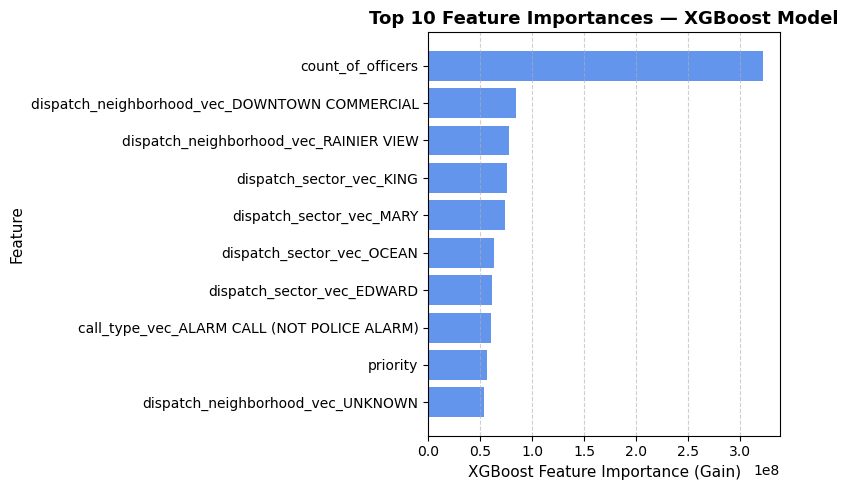

In [11]:
# ============================================================
# 7. Feature Importance Extraction and Plot
# ============================================================
from pyspark.ml.feature import OneHotEncoderModel
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Get metadata names from the features column ---
feat_name_by_idx = {}
try:
    feat_meta = pred.schema["features"].metadata
    if "ml_attr" in feat_meta and "attrs" in feat_meta["ml_attr"]:
        for k in ("binary", "numeric"):
            for a in feat_meta["ml_attr"]["attrs"].get(k, []):
                feat_name_by_idx[a["idx"]] = a.get("name", f"{k}_{a['idx']}")
except Exception as e:
    print("⚠️ Could not extract metadata from features column:", e)

# --- Step 2: Fallback: reconstruct names manually if needed ---
if not feat_name_by_idx:
    print("Reconstructing feature names using OneHotEncoderModel...")
    ohe_models = [s for s in best_model.stages if isinstance(s, OneHotEncoderModel)]
    assert len(ohe_models) == 1, "Expected a single OneHotEncoderModel stage"
    ohe_model = ohe_models[0]

    cat_vec_cols = ohe_model.getOutputCols()
    cat_sizes = ohe_model.categorySizes
    running_idx = 0

    for col_name, size in zip(cat_vec_cols, cat_sizes):
        for j in range(size):
            feat_name_by_idx[running_idx] = f"{col_name}__{j}"
            running_idx += 1

    for ncol in num_feats:
        feat_name_by_idx[running_idx] = ncol
        running_idx += 1

# --- Step 3: Extract raw feature importance scores from XGBoost ---
xgb_stage = best_model.stages[-1]
booster = xgb_stage.get_booster()
raw_imp = booster.get_score(importance_type="gain")  # {'f12': 0.123, ...}

imp_rows = []
for fid, val in raw_imp.items():
    try:
        idx = int(fid[1:])  # remove leading 'f'
        name = feat_name_by_idx.get(idx, fid)
    except Exception:
        name = fid
    imp_rows.append((name, float(val)))

imp_df = (
    pd.DataFrame(imp_rows, columns=["feature", "importance"])
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 10 Most Important Features:")
print(imp_df.head(10))

# --- Step 4: Plot top 10 features ---
topk = 10
plt.figure(figsize=(8, 5))
plt.barh(
    imp_df["feature"].head(topk)[::-1],
    imp_df["importance"].head(topk)[::-1],
    color="cornflowerblue"
)
plt.xlabel("XGBoost Feature Importance (Gain)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Top 10 Feature Importances — XGBoost Model", fontsize=13, weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()